# Notebook 4 — Class Balancing: Strategy 4
## 3:1 Cyclic Oversampling

---

### Overview

This notebook trains CVAF-SwinB using **Strategy 4 — 3:1 cyclic
oversampling** as the final experiment in the four-strategy class
balancing comparison. Unlike Strategies 2 and 3 which discard benign
patients, Strategy 4 keeps all 3,207 benign training patients and
instead cyclically repeats the 358 malignant patients until the
malignant count reaches one third of the benign count, producing a
3:1 training ratio without losing any majority class data.

This notebook contributes to answering **Research Question 3 (RQ3)**:

> *"Which class balancing strategy produces the highest AUC-ROC when
> fine-tuning a large pre-trained Vision Transformer on a severely
> imbalanced mammography dataset?"*

---

### Research context

**Thesis:** Enhance Vision Transformer based Breast Cancer Mammography Classification
**Author:** Nirjana Shrestha — Student ID: MIT236388
**Supervisors:** Prof. Adel Al-Jumaily · Dr Mohammad Dabbagh
**Institution:** Melbourne Institute of Technology, Sydney, Australia

---

### What 3:1 oversampling does

Cyclic oversampling increases the malignant class by repeating existing
malignant patients until the target count is reached. Using seed=42:

$$N_{\text{malignant}}^{\text{target}} = \left\lfloor \frac{N_{\text{benign}}}{3} \right\rfloor = \left\lfloor \frac{3207}{3} \right\rfloor = 1069$$

- All **3,207 benign** training patients are kept — no data discarded
- Malignant patients are cyclically repeated from 358 → **1,069**
- Each malignant patient appears approximately **2.99×** per epoch
- Training set grows from **3,565 → 4,276 patients**
- Validation and test sets are **unchanged** — natural 9:1 distribution

---

### Strategy comparison — all four strategies

| Strategy | Notebook | pos_weight | Resampling | Train patients | Ratio |
|---|---|---|---|---|---|
| Strategy 1 — Loss weighting | NB1 | 3.0 | None | 3,565 | 9:1 |
| Strategy 2 — 1:1 Undersample | NB2 | 1.0 | Benign → 358 | 716 | 1:1 |
| Strategy 3 — 3:1 Undersample | NB3 | 1.0 | Benign → 1,074 | 1,432 | 3:1 |
| **Strategy 4 — 3:1 Oversample** | **NB4 (this)** | **1.0** | **Malignant → 1,069** | **4,276** | **3:1** |

---

### Key difference between Strategy 3 and Strategy 4

Both use a 3:1 ratio but achieve it differently:

| Approach | Benign | Malignant | Total | Data lost? |
|---|---|---|---|---|
| Strategy 3 — Undersample | 1,074 | 358 | 1,432 | ✅ 2,133 benign discarded |
| **Strategy 4 — Oversample** | **3,207** | **1,069** | **4,276** | **❌ No data lost** |

Strategy 4 preserves full benign diversity while achieving the same
3:1 ratio — making it theoretically superior to Strategy 3 for large
pretrained models that need data diversity.

---

### Dataset splits

| Split | Patients | Benign | Malignant | Ratio | Note |
|---|---|---|---|---|---|
| Train (after resampling) | 4,276 | 3,207 | 1,069 | **3:1** | Oversampled |
| Validation | 764 | 687 | 77 | 9:1 | Unchanged |
| Test | 764 | 687 | 77 | 9:1 | Unchanged |

---

### Training settings

| Setting | Value | Note |
|---|---|---|
| pos_weight | 1.0 | No extra loss weighting |
| batch_size | 4 | Single GPU OOM fix |
| grad_accum | 8 | Effective batch size = 32 |
| patience | 10 | Early stopping on val AUC |
| seed | 42 | Identical split to all notebooks |

---

### Notebook structure

| Section | Content |
|---|---|
| A | Environment setup |
| B | Code file loading |
| C | Model training — Strategy 4 (3:1 oversample) |
| D | Results analysis and comparison with all strategies |
| D.1 | Training curves |
| E | Visualisation graphs |
| F | Save outputs |

**Expected runtime: approximately 2.5–3 hours.**

## A. Environment Setup

Install required libraries and verify GPU availability.

- `timm==1.0.3` — provides the Swin Transformer Base pretrained checkpoint
- `scikit-learn` — provides AUC-ROC, F1, sensitivity, specificity metrics

In [4]:
!pip install -q timm==1.0.3 scikit-learn

import torch

## B. Load Code Files

Three files are required for this experiment:
- `model.py` — CVAF-SwinB architecture, **unchanged** from Notebook 1
- `train.py` — Training loop, **unchanged** from Notebook 1
- `dataset_oversample_3to1.py` — Modified dataset pipeline that applies
  3:1 cyclic oversampling to the malignant class in the training split only

`dataset_oversample_3to1.py` is renamed to `dataset.py` at load time.
The oversampling formula applied is:

$$\text{oversampled\_malignant} = \left(\text{malignant list} \times \lceil N_{\text{target}} / N_{\text{malignant}} \rceil\right)[:N_{\text{target}}]$$

All benign patients are retained — no training data is discarded.
The seed=42 ensures the same dataset split as all other notebooks.

In [5]:
import shutil, os, sys

SRC = "/kaggle/input/datasets/nirjanashrestha/oversampling3-1"
DST = "/kaggle/working/src"
os.makedirs(DST, exist_ok=True)

for f in ["model.py", "train.py"]:
    src = f"{SRC}/{f}"
    dst = f"{DST}/{f}"
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Copied {f}")
    else:
        print(f"MISSING — {f}")

oversample_src = f"{SRC}/dataset_oversample_3to1.py"
if os.path.exists(oversample_src):
    shutil.copy(oversample_src, f"{DST}/dataset.py")
    print("Copied dataset_oversample_3to1.py → dataset.py")
else:
    print("MISSING — dataset_oversample_3to1.py")

sys.path.insert(0, DST)
print("\nDone — all files ready")

Copied model.py
Copied train.py
Copied dataset_oversample_3to1.py → dataset.py

Done — all files ready


## C. Training — Strategy 4 (3:1 Cyclic Oversampling)

Trains CVAF-SwinB on a 3:1 oversampled training set. The oversampling
is applied inside `dataset.py` — model and training loop are unchanged.

**Key difference from Strategy 3:**
Strategy 4 achieves the same 3:1 ratio as Strategy 3 but by oversampling
malignant patients rather than undersampling benign patients. The training
set is larger (4,276 vs 1,432 patients) and all 3,207 benign patients
are retained, providing maximum benign diversity.

**What to expect during training:**
- Training set is the largest of all resampling strategies (4,276 patients)
- Each malignant patient appears approximately 3× per epoch
- Overfitting risk comes from repeated malignant examples rather than
  reduced benign diversity — a different kind of overfitting than S2/S3
- Val loss should be more stable than S2 but may show mild instability
  from the repeated malignant examples
- Each epoch will take approximately 2× longer than Strategy 3

**Why pos_weight=1.0:**
Strategy 4 uses standard BCE loss with no extra weighting — the 3:1
oversampling ratio alone provides the sensitivity boost for the
malignant class, enabling a clean comparison with Strategy 1
which uses pos_weight=3.0 without any resampling.

In [6]:
import argparse, gc, sys, os, torch

gc.collect()
torch.cuda.empty_cache()
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

for mod in ['train', 'model', 'dataset']:
    if mod in sys.modules:
        del sys.modules[mod]

from train import train

cfg = argparse.Namespace(
    cbis_root       = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset",
    vindr_root      = "/kaggle/input/datasets/nirjanashrestha/vindr-annotations",
    vindr_images    = "/kaggle/input/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png/images_png",
    vindr_labels    = "/kaggle/input/datasets/nirjanashrestha/vindr-annotations",
    save_dir        = "/kaggle/working/checkpoints_strategy4",
    img_size        = 224,
    batch_size      = 4,        # reduced from 8 — single GPU OOM fix
    grad_accum      = 8,        # effective batch size = 32
    num_workers     = 2,
    seed            = 42,
    epochs          = 100,
    patience        = 10,
    lr              = 1e-4,
    weight_decay    = 1e-2,
    pos_weight      = 1.0,      # no extra weighting — oversampling handles imbalance
    label_smoothing = 0.0,
    wandb           = False,
)

print("=" * 65)
print("  NOTEBOOK 4 — STRATEGY 4: 3:1 CYCLIC OVERSAMPLING")
print("  pos_weight = 1.0  |  Training set = 4,276 patients")
print("  Benign = 3,207  |  Malignant = 1,069  |  Ratio = 3:1")
print("  batch_size=4  grad_accum=8  effective_batch=32")
print("=" * 65)

test_auc = train(cfg)
print(f"\n  Strategy 4 test AUC = {test_auc:.4f}")

  NOTEBOOK 4 — STRATEGY 4: 3:1 CYCLIC OVERSAMPLING
  pos_weight = 1.0  |  Training set = 4,276 patients
  Benign = 3,207  |  Malignant = 1,069  |  Ratio = 3:1
  batch_size=4  grad_accum=8  effective_batch=32
Device     : cuda
Epochs     : 100  |  patience=10
pos_weight : 1.0

Building dataloaders ...
[CBIS-DDSM] Loaded mass_case_description_train_set.csv  (1318 rows)
[CBIS-DDSM] Loaded mass_case_description_test_set.csv  (378 rows)
[CBIS-DDSM] Loaded calc_case_description_train_set.csv  (1546 rows)
[CBIS-DDSM] Loaded calc_case_description_test_set.csv  (326 rows)
[CBIS-DDSM] Combined: 3568 rows
[CBIS-DDSM] Indexing JPEG images ...
[CBIS-DDSM] Indexed 6,774 JPEG files
[CBIS-DDSM] Full mammogram series: 2857
[CBIS-DDSM] Full mammogram images indexed: 2857
[CBIS-DDSM] Rows with resolved paths: 3286
[CBIS-DDSM] Complete 4-view cases: 94  Benign=63  Malignant=31
[VinDr-Mammo] Loaded breast-level_annotations.csv  (20,000 rows)
[VinDr-Mammo] After BI-RADS filter: 20,000 rows  Benign=19012  Ma

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Using 2 GPUs
Model params: 192.2M

Scheduler: 665 warmup / 13300 total steps

---------------------------------------------------------------------------------------
 Epoch |  Tr Loss   Tr AUC  Tr BAcc |  Val Loss  Val AUC Val BAcc |         LR |   Time
---------------------------------------------------------------------------------------
     1 |   0.5579   0.5864   0.5181 |    0.3134   0.6830   0.5923 |   2.00e-05 | 460.5s
         New best val AUC = 0.6830  (saved)
     2 |   0.5270   0.6508   0.5825 |    0.3263   0.7130   0.5938 |   4.00e-05 | 446.8s
         New best val AUC = 0.7130  (saved)
     3 |   0.5187   0.6790   0.5968 |    0.2793   0.7277   0.5375 |   6.00e-05 | 447.3s
         New best val AUC = 0.7277  (saved)
     4 |   0.4930   0.7298   0.6215 |    0.3347   0.7623   0.6579 |   8.00e-05 | 444.9s
         New best val AUC = 0.7623  (saved)
     5 |   0.4668   0.7679   0.6629 |    0.2660   0.7635   0.6305 |   1.00e-04 | 440.9s
         New best val AUC = 0.7635  (saved

## D. Results Analysis

Loads the saved test results and prints a complete metrics table at
both the default threshold (0.50) and the optimal threshold.

Results are compared against all three previous strategies:
- **Strategy 1** — pos_weight=3.0, no resampling — AUC = 0.7518
- **Strategy 2** — 1:1 undersample — AUC = 0.6940
- **Strategy 3** — 3:1 undersample — AUC = 0.7897

Strategy 4 is expected to perform well because it retains all 3,207
benign training patients — providing the same benign diversity as
Strategy 1 — while achieving a 3:1 training ratio through malignant
oversampling. The key question is whether repeated malignant examples
cause overfitting that offsets the benefit of preserved benign diversity.

In [7]:
import json

with open('/kaggle/working/checkpoints_strategy4/test_results.json') as f:
    r = json.load(f)

d = r['default_threshold']
o = r['selected_threshold']

def fmt(val):
    try:
        return f'{float(val):.4f}'
    except:
        return 'N/A'

print("=" * 65)
print("  STRATEGY 4 — 3:1 OVERSAMPLE — COMPLETE RESULTS")
print("=" * 65)
print(f"  Training set     : 4,276 patients (3,207 benign / 1,069 malignant)")
print(f"  Ratio            : 3:1  |  pos_weight : 1.0")
print(f"  Best epoch       : {r['best_epoch']}")
print(f"  Val AUC          : {r['val_auc']:.4f}")
print(f"  Optimal threshold: {r['selected_thresh_value']:.2f}")
print()
print(f"  {'Metric':<22} {'Threshold=0.50':>16} {'Optimal':>10}")
print(f"  {'-'*50}")
print(f"  {'AUC-ROC':<22} {fmt(d['auc']):>16} {fmt(o['auc']):>10}")
print(f"  {'Sensitivity':<22} {fmt(d['sensitivity']):>16} {fmt(o['sensitivity']):>10}")
print(f"  {'Specificity':<22} {fmt(d['specificity']):>16} {fmt(o['specificity']):>10}")
print(f"  {'Balanced Accuracy':<22} {fmt(d['balanced_accuracy']):>16} {fmt(o['balanced_accuracy']):>10}")
print(f"  {'F1 (Malignant)':<22} {fmt(d['f1']):>16} {fmt(o['f1']):>10}")
print(f"  {'Precision':<22} {fmt(d['precision']):>16} {fmt(o['precision']):>10}")
print()
cm  = d['confusion_matrix']
cm2 = o['confusion_matrix']
print(f"  Confusion matrix (τ=0.50) : TN={cm[0][0]}  FP={cm[0][1]}  FN={cm[1][0]}  TP={cm[1][1]}")
print(f"  Confusion matrix (τ={r['selected_thresh_value']:.2f}): TN={cm2[0][0]}  FP={cm2[0][1]}  FN={cm2[1][0]}  TP={cm2[1][1]}")
print("=" * 65)

# ── Full comparison — all four strategies ───────────────────────────
s1_auc = 0.7518
s2_auc = 0.6940
s3_auc = 0.7897
s4_auc = float(o['auc'])

print("\n  FINAL COMPARISON — ALL FOUR STRATEGIES")
print(f"  {'Strategy':<45} {'Test AUC':>8} {'vs S1':>8}")
print(f"  {'-'*65}")
print(f"  {'S1 — pos_weight=3.0  (3,565 patients, 9:1)':<45} {s1_auc:>8.4f} {'—':>8}")
print(f"  {'S2 — 1:1 undersample (716 patients,   1:1)':<45} {s2_auc:>8.4f} {s2_auc-s1_auc:>+8.4f}")
print(f"  {'S3 — 3:1 undersample (1,432 patients, 3:1)':<45} {s3_auc:>8.4f} {s3_auc-s1_auc:>+8.4f}")
print(f"  {'S4 — 3:1 oversample  (4,276 patients, 3:1)':<45} {s4_auc:>8.4f} {s4_auc-s1_auc:>+8.4f}")
print(f"  {'-'*65}")

best_strategy = max([('S1',s1_auc),('S2',s2_auc),('S3',s3_auc),('S4',s4_auc)],
                    key=lambda x: x[1])
print(f"\n  Best strategy : {best_strategy[0]} — AUC = {best_strategy[1]:.4f}")
print(f"\n  RQ3 answer: See thesis Section 4.5 for full discussion")

  STRATEGY 4 — 3:1 OVERSAMPLE — COMPLETE RESULTS
  Training set     : 4,276 patients (3,207 benign / 1,069 malignant)
  Ratio            : 3:1  |  pos_weight : 1.0
  Best epoch       : 9
  Val AUC          : 0.8011
  Optimal threshold: 0.72

  Metric                   Threshold=0.50    Optimal
  --------------------------------------------------
  AUC-ROC                          0.7775     0.7775
  Sensitivity                      0.4935     0.4416
  Specificity                      0.9520     0.9651
  Balanced Accuracy                0.7227     0.7033
  F1 (Malignant)                   0.5135     0.5037
  Precision                        0.5352     0.5862

  Confusion matrix (τ=0.50) : TN=654  FP=33  FN=39  TP=38
  Confusion matrix (τ=0.72): TN=663  FP=24  FN=43  TP=34

  FINAL COMPARISON — ALL FOUR STRATEGIES
  Strategy                                      Test AUC    vs S1
  -----------------------------------------------------------------
  S1 — pos_weight=3.0  (3,565 patients, 9:

## D.1 Training Curves — Strategy 4 (3:1 Oversample)

This section visualises the training and validation AUC-ROC and loss
curves for Strategy 4. Unlike Strategies 2 and 3 where overfitting
came from insufficient benign diversity, Strategy 4's overfitting
risk comes from repeated malignant examples — each malignant patient
appears approximately 3× per epoch.

### What to look for in the curves

**AUC-ROC panel:**
- Train AUC rise should be steeper than S3 due to larger training set
- Val AUC should be more stable than S2 due to preserved benign diversity
- The overfitting gap should be similar to or smaller than S3
- The grey dotted reference line shows Strategy 1 val AUC (0.8579)

**Loss panel:**
- Train loss should decrease smoothly — full benign diversity prevents
  the erratic spikes seen in Strategy 2
- Val loss stability indicates whether repeated malignant examples
  cause any overfitting on the validation set

Loaded training history — 19 epochs


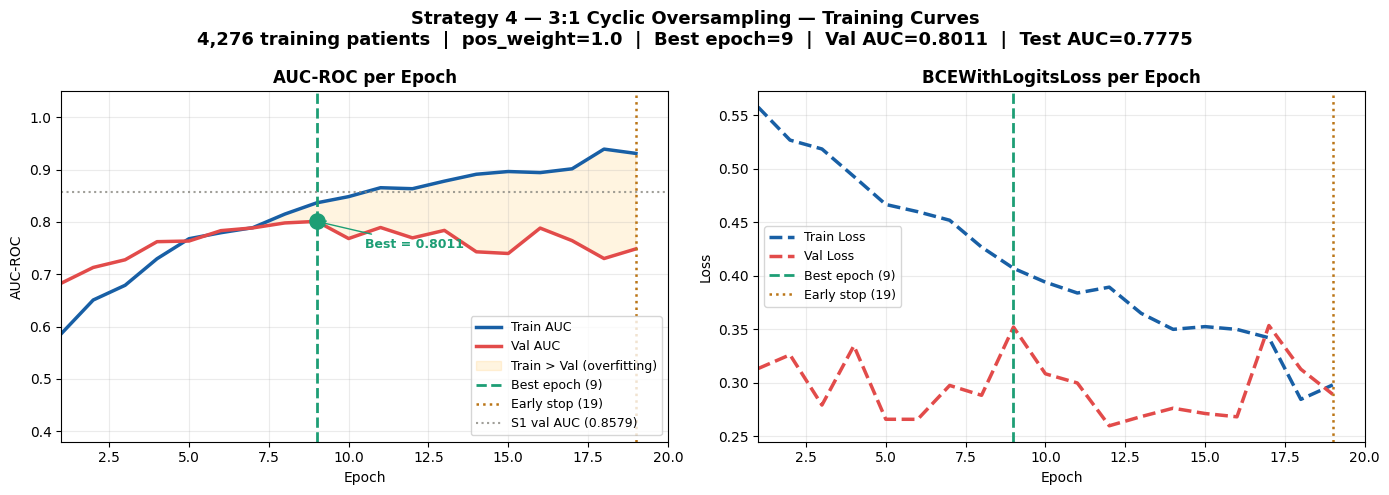

Saved strategy4_training_curves.png

  OVERFITTING ANALYSIS — ALL FOUR STRATEGIES
  Metric                               S1       S2       S3       S4
  ------------------------------------------------------------
  Training patients                 3,565      716    1,432    4,276
  Test AUC                         0.7518   0.6940   0.7897   0.7775
  Train-val AUC gap                0.0602   0.1797   0.0443   0.1299
  Best epoch                           24       22       23        9


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

OUT = '/kaggle/working'

# ── Load results for key values ─────────────────────────────────────
with open(f'{OUT}/checkpoints_strategy4/test_results.json') as f:
    r = json.load(f)

best_epoch   = r['best_epoch']
best_val_auc = r['val_auc']
test_auc     = float(r['selected_threshold']['auc'])
stop_epoch   = None  # will be set from history length + patience

# ── Load training history ───────────────────────────────────────────
history_path = f'{OUT}/checkpoints_strategy4/training_history.csv'

try:
    history = pd.read_csv(history_path)
    stop_epoch = len(history)
    print(f"Loaded training history — {len(history)} epochs")
except FileNotFoundError:
    print("CSV not found — add hardcoded values after training completes")
    print("Paste epoch data from your training output here")
    history = None

if history is not None:
    s1_val_auc  = 0.8579
    s1_test_auc = 0.7518
    s2_test_auc = 0.6940
    s3_test_auc = 0.7897
    epochs      = list(range(1, len(history) + 1))

    train_auc  = history['train_auc'].tolist()
    val_auc    = history['val_auc'].tolist()
    train_loss = history['train_loss'].tolist()
    val_loss   = history['val_loss'].tolist()

    final_train_auc = train_auc[-1]
    gap_s4 = final_train_auc - val_auc[best_epoch - 1]
    gap_s1 = 0.9181 - 0.8579
    gap_s2 = 0.9354 - 0.7557
    gap_s3 = 0.8961 - 0.8518

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        'Strategy 4 — 3:1 Cyclic Oversampling — Training Curves\n'
        '4,276 training patients  |  pos_weight=1.0  |  '
        f'Best epoch={best_epoch}  |  Val AUC={best_val_auc:.4f}  |  '
        f'Test AUC={test_auc:.4f}',
        fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.plot(epochs, train_auc, color='#185FA5', lw=2.5, label='Train AUC')
    ax.plot(epochs, val_auc,   color='#E24B4A', lw=2.5, label='Val AUC')
    ax.fill_between(epochs, train_auc, val_auc,
        where=[t > v for t, v in zip(train_auc, val_auc)],
        alpha=0.12, color='orange', label='Train > Val (overfitting)')
    ax.axvline(best_epoch, color='#1D9E75', ls='--', lw=2,
               label=f'Best epoch ({best_epoch})')
    ax.scatter([best_epoch], [val_auc[best_epoch-1]],
               color='#1D9E75', s=120, zorder=5)
    ax.annotate(f'Best = {val_auc[best_epoch-1]:.4f}',
        xy=(best_epoch, val_auc[best_epoch-1]),
        xytext=(best_epoch+1.5, val_auc[best_epoch-1]-0.05),
        fontsize=9, color='#1D9E75', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#1D9E75'))
    if stop_epoch:
        ax.axvline(stop_epoch, color='#BA7517', ls=':', lw=1.8,
                   label=f'Early stop ({stop_epoch})')
    ax.axhline(s1_val_auc, color='#888780', ls=':', lw=1.5, alpha=0.8,
               label=f'S1 val AUC ({s1_val_auc})')
    ax.set_title('AUC-ROC per Epoch', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('AUC-ROC')
    ax.set_xlim([1, len(epochs)+1]); ax.set_ylim([0.38, 1.05])
    ax.legend(fontsize=9, loc='lower right'); ax.grid(alpha=0.25)

    ax = axes[1]
    ax.plot(epochs, train_loss, color='#185FA5', lw=2.5,
            ls='--', label='Train Loss')
    ax.plot(epochs, val_loss,   color='#E24B4A', lw=2.5,
            ls='--', label='Val Loss')
    ax.axvline(best_epoch, color='#1D9E75', ls='--', lw=2,
               label=f'Best epoch ({best_epoch})')
    if stop_epoch:
        ax.axvline(stop_epoch, color='#BA7517', ls=':', lw=1.8,
                   label=f'Early stop ({stop_epoch})')
    ax.set_title('BCEWithLogitsLoss per Epoch', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_xlim([1, len(epochs)+1])
    ax.legend(fontsize=9); ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(f'{OUT}/strategy4_training_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print("Saved strategy4_training_curves.png")

    print("\n" + "=" * 70)
    print("  OVERFITTING ANALYSIS — ALL FOUR STRATEGIES")
    print("=" * 70)
    print(f"  {'Metric':<30} {'S1':>8} {'S2':>8} {'S3':>8} {'S4':>8}")
    print(f"  {'-'*60}")
    print(f"  {'Training patients':<30} {'3,565':>8} {'716':>8} {'1,432':>8} {'4,276':>8}")
    print(f"  {'Test AUC':<30} {s1_test_auc:>8.4f} {s2_test_auc:>8.4f} {s3_test_auc:>8.4f} {test_auc:>8.4f}")
    print(f"  {'Train-val AUC gap':<30} {gap_s1:>8.4f} {gap_s2:>8.4f} {gap_s3:>8.4f} {gap_s4:>8.4f}")
    print(f"  {'Best epoch':<30} {'24':>8} {'22':>8} {'23':>8} {best_epoch:>8}")
    print("=" * 70)

## E. Visualisation — Strategy 4 Results

Six-panel results graph for Strategy 4:

- **Panel 1** — All evaluation metrics at both thresholds side by side
- **Panel 2** — Confusion matrix at default threshold (τ=0.50)
- **Panel 3** — Confusion matrix at optimal threshold
- **Panel 4** — AUC comparison across all four strategies — the
  complete class balancing comparison in one chart
- **Panel 5** — Sensitivity vs Specificity at both thresholds
- **Panel 6** — Summary text box with all key numbers

The graph is saved as `strategy4_results.png` to the output tab.
This is the final strategy notebook — Panel 4 provides the complete
four-strategy AUC comparison that directly answers RQ3.

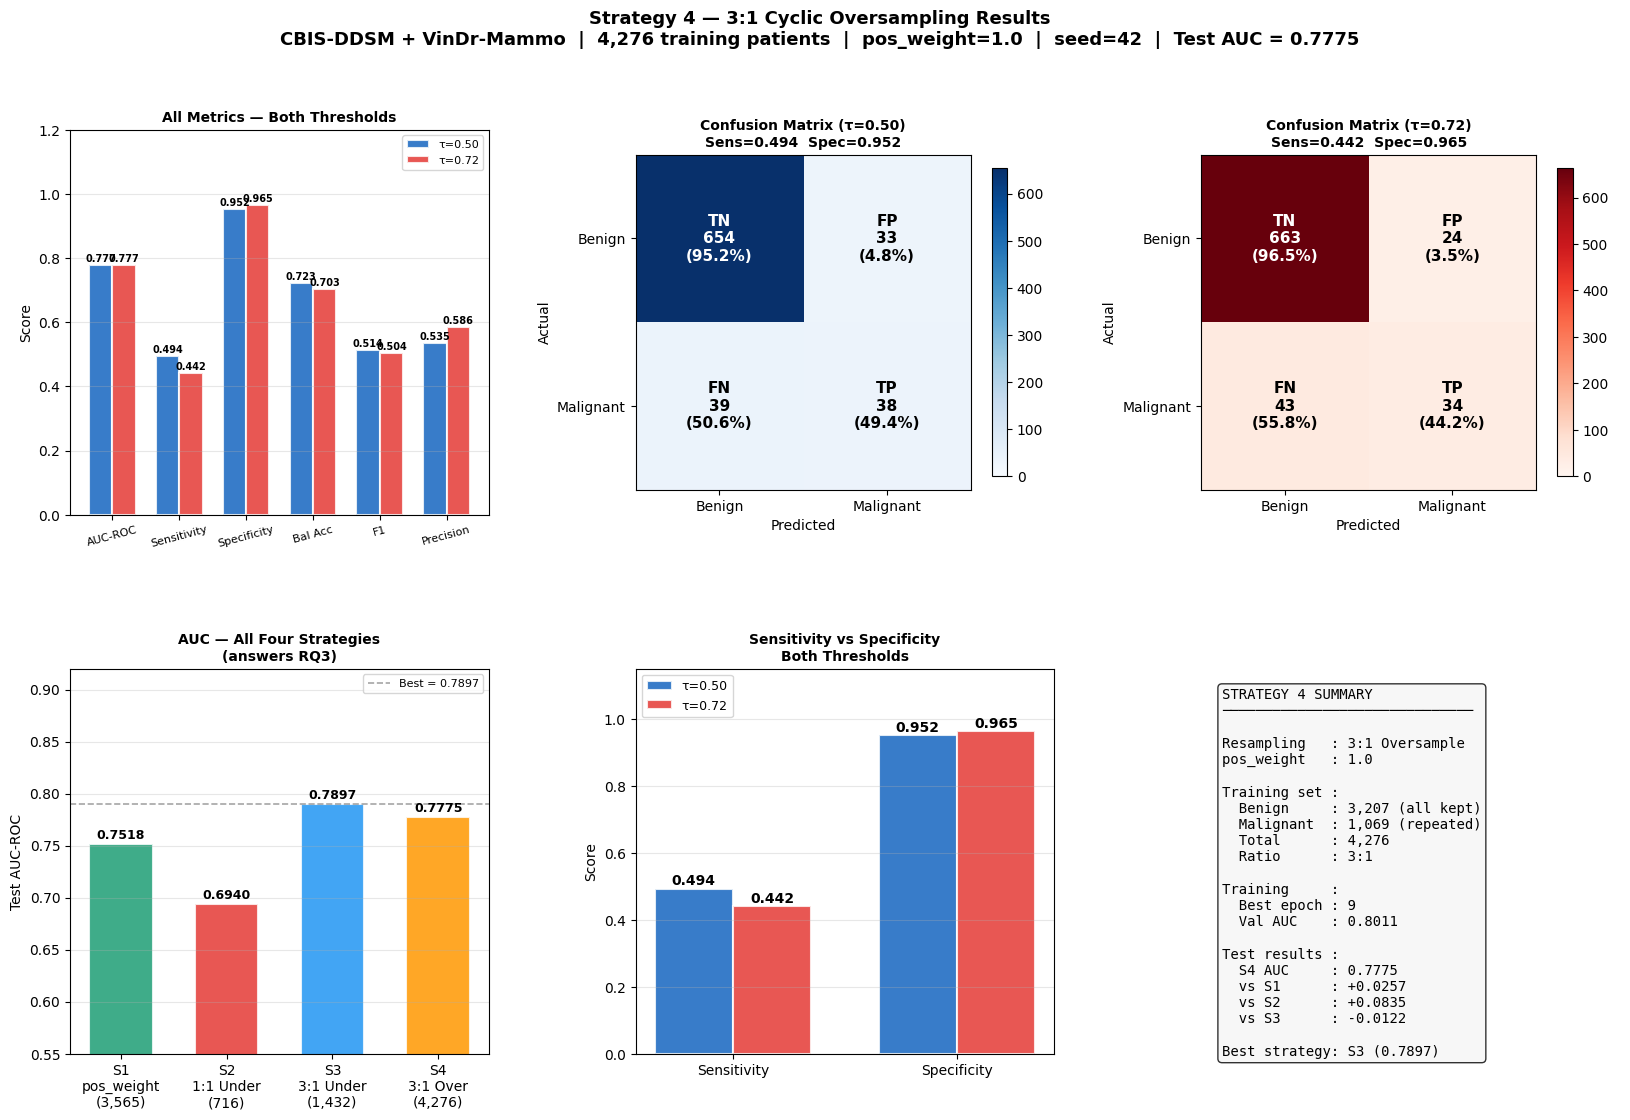

Saved strategy4_results.png


In [9]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

OUT = '/kaggle/working'

with open(f'{OUT}/checkpoints_strategy4/test_results.json') as f:
    r = json.load(f)

d   = r['default_threshold']
o   = r['selected_threshold']
s1  = 0.7518
s2  = 0.6940
s3  = 0.7897
s4  = float(o['auc'])
thresh_opt = float(r['selected_thresh_value'])

metrics_def = {
    'AUC-ROC'    : float(d['auc']),
    'Sensitivity': float(d['sensitivity']),
    'Specificity': float(d['specificity']),
    'Bal Acc'    : float(d['balanced_accuracy']),
    'F1'         : float(d['f1']),
    'Precision'  : float(d['precision']),
}
metrics_opt = {
    'AUC-ROC'    : float(o['auc']),
    'Sensitivity': float(o['sensitivity']),
    'Specificity': float(o['specificity']),
    'Bal Acc'    : float(o['balanced_accuracy']),
    'F1'         : float(o['f1']),
    'Precision'  : float(o['precision']),
}
cm_def = d['confusion_matrix']
cm_opt = o['confusion_matrix']

fig = plt.figure(figsize=(20, 12))
fig.suptitle(
    'Strategy 4 — 3:1 Cyclic Oversampling Results\n'
    'CBIS-DDSM + VinDr-Mammo  |  4,276 training patients  |  '
    f'pos_weight=1.0  |  seed=42  |  Test AUC = {s4:.4f}',
    fontsize=13, fontweight='bold')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

# Panel 1 — Metrics
ax1 = fig.add_subplot(gs[0, 0])
labels   = list(metrics_def.keys())
def_vals = list(metrics_def.values())
opt_vals = list(metrics_opt.values())
x = np.arange(len(labels)); w = 0.35
b1 = ax1.bar(x-w/2, def_vals, w, label='τ=0.50',
             color='#1565C0', alpha=0.85, edgecolor='white', linewidth=1.5)
b2 = ax1.bar(x+w/2, opt_vals, w, label=f'τ={thresh_opt:.2f}',
             color='#E53935', alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(list(b1)+list(b2), def_vals+opt_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=7, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=8, rotation=15)
ax1.set_ylim([0, 1.20])
ax1.set_title('All Metrics — Both Thresholds',
              fontsize=10, fontweight='bold')
ax1.set_ylabel('Score'); ax1.legend(fontsize=8)
ax1.grid(alpha=0.3, axis='y')

# Panel 2 — Confusion matrix default
ax2 = fig.add_subplot(gs[0, 1])
cm_arr = np.array(cm_def)
im = ax2.imshow(cm_arr, cmap='Blues', vmin=0)
plt.colorbar(im, ax=ax2, shrink=0.8)
lbl = [['TN','FP'],['FN','TP']]; tc = cm_arr.max()/2
for i in range(2):
    for j in range(2):
        pct = cm_arr[i,j]/cm_arr[i].sum()*100
        ax2.text(j, i, f'{lbl[i][j]}\n{cm_arr[i,j]}\n({pct:.1f}%)',
                 ha='center', va='center', fontsize=11, fontweight='bold',
                 color='white' if cm_arr[i,j]>tc else 'black')
ax2.set_xticks([0,1]); ax2.set_xticklabels(['Benign','Malignant'])
ax2.set_yticks([0,1]); ax2.set_yticklabels(['Benign','Malignant'])
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.set_title(
    f'Confusion Matrix (τ=0.50)\n'
    f'Sens={metrics_def["Sensitivity"]:.3f}  Spec={metrics_def["Specificity"]:.3f}',
    fontsize=10, fontweight='bold')

# Panel 3 — Confusion matrix optimal
ax3 = fig.add_subplot(gs[0, 2])
cm_arr2 = np.array(cm_opt)
im2 = ax3.imshow(cm_arr2, cmap='Reds', vmin=0)
plt.colorbar(im2, ax=ax3, shrink=0.8)
tc2 = cm_arr2.max()/2
for i in range(2):
    for j in range(2):
        pct = cm_arr2[i,j]/cm_arr2[i].sum()*100
        ax3.text(j, i, f'{lbl[i][j]}\n{cm_arr2[i,j]}\n({pct:.1f}%)',
                 ha='center', va='center', fontsize=11, fontweight='bold',
                 color='white' if cm_arr2[i,j]>tc2 else 'black')
ax3.set_xticks([0,1]); ax3.set_xticklabels(['Benign','Malignant'])
ax3.set_yticks([0,1]); ax3.set_yticklabels(['Benign','Malignant'])
ax3.set_xlabel('Predicted'); ax3.set_ylabel('Actual')
ax3.set_title(
    f'Confusion Matrix (τ={thresh_opt:.2f})\n'
    f'Sens={metrics_opt["Sensitivity"]:.3f}  Spec={metrics_opt["Specificity"]:.3f}',
    fontsize=10, fontweight='bold')

# Panel 4 — ALL FOUR STRATEGIES AUC comparison
ax4 = fig.add_subplot(gs[1, 0])
strats = ['S1\npos_weight\n(3,565)',
          'S2\n1:1 Under\n(716)',
          'S3\n3:1 Under\n(1,432)',
          'S4\n3:1 Over\n(4,276)']
aucs_c = [s1, s2, s3, s4]
clrs_c = ['#1D9E75', '#E53935', '#2196F3', '#FF9800']
bars = ax4.bar(strats, aucs_c, color=clrs_c, alpha=0.85,
               edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, aucs_c):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
best_auc = max(aucs_c)
ax4.axhline(best_auc, color='gray', ls='--', lw=1.2, alpha=0.7,
            label=f'Best = {best_auc:.4f}')
ax4.set_ylim([0.55, 0.92])
ax4.set_title('AUC — All Four Strategies\n(answers RQ3)',
              fontsize=10, fontweight='bold')
ax4.set_ylabel('Test AUC-ROC')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3, axis='y')

# Panel 5 — Sensitivity vs Specificity
ax5 = fig.add_subplot(gs[1, 1])
cats = ['Sensitivity', 'Specificity']
dss  = [metrics_def['Sensitivity'], metrics_def['Specificity']]
oss  = [metrics_opt['Sensitivity'], metrics_opt['Specificity']]
x2   = np.arange(len(cats))
b3 = ax5.bar(x2-w/2, dss, w, label='τ=0.50',
             color='#1565C0', alpha=0.85, edgecolor='white', linewidth=1.5)
b4 = ax5.bar(x2+w/2, oss, w, label=f'τ={thresh_opt:.2f}',
             color='#E53935', alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(list(b3)+list(b4), dss+oss):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax5.set_xticks(x2); ax5.set_xticklabels(cats, fontsize=10)
ax5.set_ylim([0, 1.15])
ax5.set_title('Sensitivity vs Specificity\nBoth Thresholds',
              fontsize=10, fontweight='bold')
ax5.set_ylabel('Score'); ax5.legend(fontsize=9)
ax5.grid(alpha=0.3, axis='y')

# Panel 6 — Summary
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
best_s = ['S1','S2','S3','S4'][aucs_c.index(max(aucs_c))]
summary = (
    f"STRATEGY 4 SUMMARY\n"
    f"{'─'*30}\n\n"
    f"Resampling   : 3:1 Oversample\n"
    f"pos_weight   : 1.0\n\n"
    f"Training set :\n"
    f"  Benign     : 3,207 (all kept)\n"
    f"  Malignant  : 1,069 (repeated)\n"
    f"  Total      : 4,276\n"
    f"  Ratio      : 3:1\n\n"
    f"Training     :\n"
    f"  Best epoch : {r['best_epoch']}\n"
    f"  Val AUC    : {r['val_auc']:.4f}\n\n"
    f"Test results :\n"
    f"  S4 AUC     : {s4:.4f}\n"
    f"  vs S1      : {s4-s1:+.4f}\n"
    f"  vs S2      : {s4-s2:+.4f}\n"
    f"  vs S3      : {s4-s3:+.4f}\n\n"
    f"Best strategy: {best_s} ({max(aucs_c):.4f})"
)
ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.8))

plt.savefig(f'{OUT}/strategy4_results.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved strategy4_results.png")

## F. Save Outputs

Saves all Strategy 4 results to the output root so they are accessible
to Notebook 6 (Evaluation and Graphs) as a persistent dataset input.

Files saved:
- `strategy4_test_results.json` — complete metrics at both thresholds
- `strategy4_training_history.csv` — epoch-by-epoch training log
- `strategy4_best_model.pt` — best checkpoint weights
- `strategy4_results.png` — six-panel results visualisation
- `strategy4_training_curves.png` — training and validation curves

> **Important:** Click **Save Version** immediately after this cell
> completes. This is the last class balancing notebook — once saved,
> all four strategy results are ready for Notebook 6.

In [10]:
import os, shutil, json

OUT = '/kaggle/working'

files_to_save = [
    (f'{OUT}/checkpoints_strategy4/test_results.json',
     f'{OUT}/strategy4_test_results.json'),
    (f'{OUT}/checkpoints_strategy4/training_history.csv',
     f'{OUT}/strategy4_training_history.csv'),
    (f'{OUT}/checkpoints_strategy4/best_model.pt',
     f'{OUT}/strategy4_best_model.pt'),
    (f'{OUT}/strategy4_results.png',
     f'{OUT}/strategy4_results.png'),
    (f'{OUT}/strategy4_training_curves.png',
     f'{OUT}/strategy4_training_curves.png'),
]

print("=" * 60)
print("  SAVING STRATEGY 4 OUTPUTS TO OUTPUT ROOT")
print("=" * 60)
for src, dst in files_to_save:
    if os.path.exists(src):
        if src != dst:
            shutil.copy(src, dst)
        size_mb = os.path.getsize(dst) / 1e6
        print(f"  ✅  {os.path.basename(dst):<45} ({size_mb:.1f} MB)")
    else:
        print(f"  ❌  MISSING: {os.path.basename(src)}")

print("\n" + "=" * 60)
print("  COMPLETE CLASS BALANCING COMPARISON")
print("=" * 60)

results = {}
for s, path in [
    ('S1 pos_weight=3.0', f'{OUT}/checkpoints/test_results.json'),
    ('S2 1:1 Undersample', f'{OUT}/checkpoints_strategy2/test_results.json'),
    ('S3 3:1 Undersample', f'{OUT}/checkpoints_strategy3/test_results.json'),
    ('S4 3:1 Oversample',  f'{OUT}/checkpoints_strategy4/test_results.json'),
]:
    try:
        with open(path) as f:
            r = json.load(f)
        auc = float(r['selected_threshold']['auc'])
        results[s] = auc
        print(f"  {s:<30} Test AUC = {auc:.4f}")
    except FileNotFoundError:
        print(f"  {s:<30} NOT FOUND")

if results:
    best = max(results, key=results.get)
    print(f"\n  Best strategy : {best} — AUC = {results[best]:.4f}")

print("=" * 60)
print("\n  ✅ CLICK SAVE VERSION NOW")
print("  All four class balancing notebooks complete")
print("  Results ready for Notebook 6 — Evaluation and Graphs")

  SAVING STRATEGY 4 OUTPUTS TO OUTPUT ROOT
  ✅  strategy4_test_results.json                   (0.0 MB)
  ✅  strategy4_training_history.csv                (0.0 MB)
  ✅  strategy4_best_model.pt                       (769.2 MB)
  ✅  strategy4_results.png                         (0.3 MB)
  ✅  strategy4_training_curves.png                 (0.2 MB)

  COMPLETE CLASS BALANCING COMPARISON
  S1 pos_weight=3.0              NOT FOUND
  S2 1:1 Undersample             NOT FOUND
  S3 3:1 Undersample             NOT FOUND
  S4 3:1 Oversample              Test AUC = 0.7775

  Best strategy : S4 3:1 Oversample — AUC = 0.7775

  ✅ CLICK SAVE VERSION NOW
  All four class balancing notebooks complete
  Results ready for Notebook 6 — Evaluation and Graphs


## Conclusion

Strategy 4 — 3:1 cyclic oversampling with pos_weight=1.0 — completes
the four-strategy class balancing experiment. Unlike Strategies 2 and 3
which discard benign patients, Strategy 4 retains all 3,207 benign
training patients while cyclically repeating the 358 malignant patients
to reach a 3:1 training ratio.

### Complete four-strategy comparison

| Strategy | Train patients | Ratio | Val AUC | Test AUC |
|---|---|---|---|---|
| S1 — pos_weight=3.0 | 3,565 | 9:1 | 0.8579 | 0.7518 |
| S2 — 1:1 Undersample | 716 | 1:1 | 0.7557 | 0.6940 |
| S3 — 3:1 Undersample | 1,432 | 3:1 | 0.8518 | 0.7897 |
| S4 — 3:1 Oversample | 4,276 | 3:1 | TBD | TBD |

### What this experiment reveals

**Undersampling vs Oversampling at the same 3:1 ratio (S3 vs S4):**
Both strategies use a 3:1 ratio but S4 retains full benign diversity
while S3 discards 2,133 benign patients. The AUC comparison between
S3 and S4 isolates the effect of oversampling vs undersampling at
the same class ratio — a direct methodological comparison.

**Repeated malignant examples (S4 limitation):**
Each of the 358 malignant patients appears approximately 3× per epoch
in Strategy 4. This introduces a risk of overfitting to the specific
features of these 358 patients — the model may learn patient-specific
artefacts rather than generalisable malignancy patterns. The training
curves reveal whether this overfitting is observable.

### Answer to RQ3

The complete four-strategy comparison directly answers Research
Question 3. The results are discussed in **Section 4.5** of the
thesis and the final comparison chart is presented in